<img src="./Imagenes/logo_UTN.svg" align="right" width="150" />

#### Teoría de los Circuitos II

# Trabajo Semanal 6
#### Alumno: Lucas Gallero
#### Profesor: Mariano Llamedo Soria
#### Ayudante de TPs: David Moharos
----

# Enunciado:

A partir del siguiente esquema:

<div align="center">
    <img src="./Imagenes/enunciado.png" alt="Enunciado de filtros digitales" width="600"/>
</div>

## Se pide

### 1. Comprobar que el esquema se corresponde con la siguiente transferencia

$$
H(z) = \left(1 - c_1 z^{-N}\right)
\cdot
\frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}
{\frac{1}{a_0} - a_1 z^{-1} - a_2 z^{-2}}
$$

### 2. Filtro de media móvil (moving average o CIC: cascaded integrator comb)

- Verificar la transferencia para $a_0 = 1$, $a_1 = 1$, $b_0 = 1/N$, $c_1 = 1$ y $N = 3, 4$ y $5$.
- ¿Es un filtro IIR o FIR? Discuta las ventajas que tendría esta implementación respecto al filtro FIR de media móvil 3.
- ¿Podría implementar el siguiente sistema $h(k) = (1, 1, 1, 1, 1, 1, 1)$ con esta topología?

### 3. Filtro diferenciador (differentiator)

- Obtener los valores de $a_i$ y $b_k$ para obtener:

  $$
  y(n) = \frac{x(n) - x(n-2)}{2}
  $$

- Evaluar al sistema con un seno discreto en Python y comprobar si la salida se aproxima a la derivada.

### 4. Filtro elimina continua (DC Blocker)

- Verifique la transferencia para $a_0 = 1$, $a_1 = \beta$, $b_0 = 1$, $b_1 = -1$ para $\beta = 0.9$.
- Determine $\beta$ para que la transferencia en $\Omega = 0{,}1 \cdot \pi$ sea 3 dB menor a la transferencia en $\Omega = \pi$.

### 5. Filtro peine (Comb filter)

- Verifique la transferencia para $c_1 = -1$ y $N = 8$.
- Proponga una $f_{\text{sampling}}$ y halle las frecuencias donde se generan los peaks y los nulls en el espectro.

**Importante:** *Para los siguientes incisos calcular y representar sus singularidades en el plano $z$, su respuesta de módulo y fase de $H(z)$ y su diagrama en bloques. Cuando no se indique considerar los coeficientes igual a cero.*

## Bonus

- 🏅 Verificar en Python el punto 3) con la función `diff`.
- 🏅 Utilizando solo el *biquad*, hallar los valores de los coeficientes para emular la respuesta analógica de un pasatodo de orden 1. Utilice alguno de los métodos de diseño vistos en clases.




In [1]:
# Librerías utilizadas para el análisis de filtros digitales
import numpy as np
import scipy.signal as sig
from scipy.fftpack import diff
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import display, Math

%matplotlib inline
sp.init_printing()

fig_sz_x = 13
fig_sz_y = 5
fig_dpi = 100
fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size': fig_font_size})

# Las librerías se cargan una sola vez.
# freqz y lfilter trabajan con coeficientes de potencias de z^-1.

---
# Resolución

Se trabaja con condiciones iniciales nulas. La frecuencia digital se expresa en radianes por muestra:

$$
\Omega=2\pi\frac{f}{f_s},\qquad T_s=\frac{1}{f_s}
$$

La respuesta en frecuencia se obtiene evaluando $z=e^{j\Omega}$. En consecuencia, $\Omega=0$ corresponde a continua y $\Omega=\pi$ a Nyquist.

## <ins>Funciones utilizadas para la verificación</ins>

Se define una función para simular el esquema original y otra para representar el módulo, la fase y las singularidades. En los gráficos de módulo se adopta un límite inferior de $-100\,\mathrm{dB}$; en los nulos exactos el valor ideal es $-\infty\,\mathrm{dB}$ y la fase no está definida.

Todas las gráficas de fase se expresan en grados. Para calcular el retardo de grupo se utiliza la fase en radianes.


In [2]:
def filtrar_esquema(x, N=1, c1=0, a0=1, a1=0, a2=0,
                    b0=1, b1=0, b2=0):
    # Estados de la cadena de dos demoras del biquad.
    w_1 = 0.0
    w_2 = 0.0
    y = np.zeros(len(x), dtype=float)

    for n in range(len(x)):
        x_N = x[n-N] if n >= N else 0.0
        u = x[n] - c1*x_N
        w = a0*(u + a1*w_1 + a2*w_2)
        y[n] = b0*w + b1*w_1 + b2*w_2

        # Las memorias se actualizan después de calcular la salida.
        w_2 = w_1
        w_1 = w

    return y

In [3]:
def graficar_filtro(num, den, ceros, polos, titulo, fs=None):
    ceros = np.asarray(ceros, dtype=complex)
    polos = np.asarray(polos, dtype=complex)

    # Se incluyen exactamente las frecuencias de los ceros unitarios.
    ceros_unitarios = ceros[np.isclose(np.abs(ceros), 1)]
    nulos = np.abs(np.angle(ceros_unitarios))
    omega = np.unique(np.r_[np.linspace(0, np.pi, 4097), nulos])
    _, H = sig.freqz(num, den, worN=omega)
    modulo = np.abs(H)
    modulo_db = 20*np.log10(np.maximum(modulo, 1e-5))
    fase = np.angle(H, deg=True)
    fase[modulo < 1e-10] = np.nan

    frecuencia = omega/np.pi if fs is None else omega*fs/(2*np.pi)
    etiqueta = r'Frecuencia normalizada $\Omega/\pi$' if fs is None else 'Frecuencia [Hz]'
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))

    axes[0].plot(frecuencia, modulo_db)
    axes[0].set_title('Respuesta de módulo')
    axes[0].set_ylabel('Módulo [dB]')
    if np.ptp(modulo_db) < 1e-8:
        axes[0].set_ylim(-0.1, 0.1)
    axes[1].plot(frecuencia, fase, color='tab:green')
    axes[1].set_title('Respuesta de fase')
    axes[1].set_ylabel('Fase [°]')
    for ax in axes[:2]:
        ax.set_xlabel(etiqueta)
        ax.set_xlim(frecuencia[0], frecuencia[-1])
        ax.grid(True, alpha=0.3)

    angulo = np.linspace(0, 2*np.pi, 721)
    axes[2].plot(np.cos(angulo), np.sin(angulo), 'k--', alpha=0.4)
    axes[2].axhline(0, color='gray', lw=0.7)
    axes[2].axvline(0, color='gray', lw=0.7)
    axes[2].scatter(ceros.real, ceros.imag, facecolors='none',
                    edgecolors='tab:blue', s=65, linewidths=1.7)
    valores, cantidades = np.unique(np.round(polos, 12), return_counts=True)
    axes[2].scatter(valores.real, valores.imag, marker='x',
                    color='tab:red', s=65, linewidths=1.7)
    for polo, cantidad in zip(valores, cantidades):
        if cantidad > 1:
            axes[2].annotate(f'multiplicidad {cantidad}', (polo.real, polo.imag),
                             xytext=(6, -18), textcoords='offset points', fontsize=9)
    limite = 1.15*max(1, np.max(np.abs(np.r_[ceros, polos]), initial=0))
    axes[2].set(xlim=(-limite, limite), ylim=(-limite, limite),
                xlabel='Parte real', ylabel='Parte imaginaria',
                title='Polos (×) y ceros (○)')
    axes[2].set_aspect('equal')
    fig.suptitle(titulo)
    fig.tight_layout()
    plt.show()

---
# 1) Comprobación de la función transferencia

Se divide el esquema en dos etapas en cascada: un filtro peine y una sección recursiva de segundo orden (*biquad*). Se consideran condiciones iniciales nulas para obtener la transferencia mediante la transformada Z.

## <ins>Etapa peine</ins>

Se denomina $u[n]$ a la salida de la primera etapa. El bloque $z^{-N}$ introduce un retardo de $N$ muestras, mientras que $c_1$ multiplica la señal retardada. Como esta rama ingresa con signo negativo al sumador:

$$u[n]=x[n]-c_1x[n-N]$$

Aplicando la transformada Z:

$$U(z)=X(z)-c_1z^{-N}X(z)$$

Por lo tanto, la transferencia de la etapa peine resulta:

$$\boxed{H_{\text{peine}}(z)=\frac{U(z)}{X(z)}=1-c_1z^{-N}}$$


## <ins>Sección recursiva de segundo orden</ins>

Se denomina $w[n]$ a la señal ubicada **a la salida del multiplicador $a_0$**. Los dos retardos consecutivos generan las señales $w[n-1]$ y $w[n-2]$, que se realimentan mediante los coeficientes $a_1$ y $a_2$.

Como $a_0$ se encuentra después del sumador, multiplica tanto a la entrada como a los términos de realimentación:

$$w[n]=a_0\left(u[n]+a_1w[n-1]+a_2w[n-2]\right)$$

Aplicando la transformada Z:

$$W(z)=a_0\left(U(z)+a_1z^{-1}W(z)+a_2z^{-2}W(z)\right)$$

Se agrupan los términos que contienen $W(z)$:

$$W(z)-a_0a_1z^{-1}W(z)-a_0a_2z^{-2}W(z)=a_0U(z)$$

Extrayendo factor común y despejando:

$$\frac{W(z)}{U(z)}=\frac{a_0}{1-a_0a_1z^{-1}-a_0a_2z^{-2}}$$

Para $a_0\neq0$, se divide el numerador y el denominador por $a_0$:

$$\boxed{\frac{W(z)}{U(z)}=\frac{1}{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}}$$

Los signos negativos del denominador aparecen al pasar los términos de realimentación al miembro izquierdo.

Por otra parte, el sumador de salida combina $w[n]$ y sus dos versiones retardadas, ponderadas por $b_0$, $b_1$ y $b_2$:

$$y[n]=b_0w[n]+b_1w[n-1]+b_2w[n-2]$$

Transformando y extrayendo factor común:

$$Y(z)=\left(b_0+b_1z^{-1}+b_2z^{-2}\right)W(z)$$

Entonces:

$$\frac{Y(z)}{W(z)}=b_0+b_1z^{-1}+b_2z^{-2}$$

La transferencia completa del biquad se obtiene multiplicando ambas relaciones:

$$H_{\text{biquad}}(z)=\frac{Y(z)}{W(z)}\frac{W(z)}{U(z)}$$

$$\boxed{H_{\text{biquad}}(z)=\frac{b_0+b_1z^{-1}+b_2z^{-2}}{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}}$$

## <ins>Transferencia total</ins>

Al estar las dos etapas conectadas en cascada, sus transferencias se multiplican:

$$H(z)=\frac{Y(z)}{X(z)}=\frac{Y(z)}{U(z)}\frac{U(z)}{X(z)}$$

Reemplazando las expresiones obtenidas:

$$\boxed{H(z)=\left(1-c_1z^{-N}\right)\frac{b_0+b_1z^{-1}+b_2z^{-2}}{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}}$$

Se comprueba que la transferencia deducida del esquema coincide con la indicada en el enunciado.

### <ins>Verificación simbólica</ins>


In [4]:
# Variables simbólicas
z = sp.symbols('z', nonzero=True)
N_s = sp.symbols('N', integer=True, positive=True)
X, U, W, Y = sp.symbols('X U W Y')
a0 = sp.symbols('a_0', nonzero=True)
a1, a2 = sp.symbols('a_1 a_2')
b0, b1, b2, c1 = sp.symbols('b_0 b_1 b_2 c_1')

sistema = sp.solve([
    U - (1-c1*z**(-N_s))*X,
    W - a0*(U + a1*z**(-1)*W + a2*z**(-2)*W),
    Y - (b0+b1*z**(-1)+b2*z**(-2))*W
], [U, W, Y], dict=True)[0]

H_obtenida = sp.factor(sistema[Y]/X)
H_esperada = (1-c1*z**(-N_s))*(b0+b1/z+b2/z**2)/(1/a0-a1/z-a2/z**2)
verificacion = sp.simplify(H_obtenida-H_esperada)

display(Math(r'H(z)=' + sp.latex(H_obtenida)))
assert verificacion == 0
print('✓ La diferencia entre ambas transferencias es cero.')

<IPython.core.display.Math object>

✓ La diferencia entre ambas transferencias es cero.


---
# 2) Filtro de media móvil

## <ins>Obtención de la transferencia</ins>

Se parte de la transferencia general del esquema:

$$
H(z)=(1-c_1z^{-N})\frac{b_0+b_1z^{-1}+b_2z^{-2}}{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}
$$

Se reemplazan los coeficientes indicados:

$$
a_0=1,\qquad a_1=1,\qquad b_0=\frac{1}{N},\qquad c_1=1
$$

Los coeficientes restantes se consideran nulos: $a_2=b_1=b_2=0$. Entonces:

$$
H(z)=(1-z^{-N})\frac{\frac{1}{N}}{1-z^{-1}}
\qquad\Rightarrow\qquad
\boxed{H(z)=\frac{1}{N}\frac{1-z^{-N}}{1-z^{-1}}}
$$

Para expresar esta transferencia como una suma de retardos, se desarrolla el siguiente producto:

$$
\begin{aligned}
&(1-z^{-1})(1+z^{-1}+\cdots+z^{-(N-1)})\\
&=(1+z^{-1}+\cdots+z^{-(N-1)})-(z^{-1}+z^{-2}+\cdots+z^{-N})\\
&=1-z^{-N}
\end{aligned}
$$

Los términos intermedios se cancelan. Por lo tanto:

$$
H(z)=\frac{1}{N}\frac{(1-z^{-1})(1+z^{-1}+\cdots+z^{-(N-1)})}{1-z^{-1}}
$$

Cancelando el factor común:

$$
\boxed{H(z)=\frac{1}{N}(1+z^{-1}+\cdots+z^{-(N-1)})}
$$

Como $Y(z)=H(z)X(z)$:

$$
Y(z)=\frac{1}{N}\left(X(z)+z^{-1}X(z)+\cdots+z^{-(N-1)}X(z)\right)
$$

Cada factor $z^{-k}$ representa un retardo de $k$ muestras. Aplicando la transformada Z inversa:

$$
\boxed{y[n]=\frac{1}{N}\left(x[n]+x[n-1]+\cdots+x[n-(N-1)]\right)}
$$

La salida corresponde al promedio de las últimas $N$ muestras de entrada.

## <ins>Transferencias y respuestas al impulso</ins>

La respuesta al impulso se obtiene aplicando una entrada $x[n]=\delta[n]$. Como $X(z)=1$, resulta $Y(z)=H(z)$. Se utiliza la correspondencia:

$$z^{-k}\ \longleftrightarrow\ \delta[n-k]$$


### Para $N=3$

$$H_3(z)=\frac{1}{3}\left(1+z^{-1}+z^{-2}\right)$$

Aplicando la transformada Z inversa:

$$h_3[n]=\frac{1}{3}\left(\delta[n]+\delta[n-1]+\delta[n-2]\right)$$

$$
\boxed{h_3[n]=\begin{cases}
\frac{1}{3},&0\leq n\leq 2\\
0,&\text{en otro caso}
\end{cases}}
$$

La respuesta tiene 3 muestras no nulas, por lo que corresponde a un **FIR de orden 2**.


### Para $N=4$

$$H_4(z)=\frac{1}{4}\left(1+z^{-1}+z^{-2}+z^{-3}\right)$$

Aplicando la transformada Z inversa:

$$h_4[n]=\frac{1}{4}\left(\delta[n]+\delta[n-1]+\delta[n-2]+\delta[n-3]\right)$$

$$
\boxed{h_4[n]=\begin{cases}
\frac{1}{4},&0\leq n\leq 3\\
0,&\text{en otro caso}
\end{cases}}
$$

La respuesta tiene 4 muestras no nulas, por lo que corresponde a un **FIR de orden 3**.


### Para $N=5$

$$H_5(z)=\frac{1}{5}\left(1+z^{-1}+z^{-2}+z^{-3}+z^{-4}\right)$$

Aplicando la transformada Z inversa:

$$h_5[n]=\frac{1}{5}\left(\delta[n]+\delta[n-1]+\delta[n-2]+\delta[n-3]+\delta[n-4]\right)$$

$$
\boxed{h_5[n]=\begin{cases}
\frac{1}{5},&0\leq n\leq 4\\
0,&\text{en otro caso}
\end{cases}}
$$

La respuesta tiene 5 muestras no nulas, por lo que corresponde a un **FIR de orden 4**.

En los tres casos, la respuesta al impulso se anula después de una cantidad finita de muestras. Por lo tanto, el sistema equivalente es FIR, aunque el esquema original utilice realimentación.

In [5]:
for N in [3, 4, 5]:
    H_recursiva = sp.Rational(1, N)*(1-z**(-N))/(1-z**(-1))
    H_fir = sum(z**(-k) for k in range(N))/N

    assert sp.cancel(H_recursiva-H_fir) == 0
    display(Math(r'H_' + str(N) + r'(z)=' + sp.latex(sp.expand(H_fir))))
    print(f'N={N}: se verifica la equivalencia entre ambas expresiones.')

<IPython.core.display.Math object>

N=3: se verifica la equivalencia entre ambas expresiones.


<IPython.core.display.Math object>

N=4: se verifica la equivalencia entre ambas expresiones.


<IPython.core.display.Math object>

N=5: se verifica la equivalencia entre ambas expresiones.


## <ins>Implementación recursiva y diagrama en bloques</ins>

Se parte de:

$$\frac{Y(z)}{X(z)}=\frac{1}{N}\frac{1-z^{-N}}{1-z^{-1}}$$

Multiplicando y distribuyendo:

$$ (1-z^{-1})Y(z)=\frac{1}{N}(1-z^{-N})X(z) $$

$$Y(z)-z^{-1}Y(z)=\frac{1}{N}X(z)-\frac{1}{N}z^{-N}X(z)$$

Aplicando la transformada Z inversa y despejando:

$$\boxed{y[n]=y[n-1]+\frac{x[n]-x[n-N]}{N}}$$

Esta expresión actualiza el promedio anterior sumando la contribución de la muestra nueva y restando la de la muestra que abandona la ventana.

En el esquema original, las señales internas cumplen:

$$u[n]=x[n]-x[n-N]$$

$$w[n]=u[n]+w[n-1],\qquad y[n]=\frac{w[n]}{N}$$

La implementación se compone de una etapa peine, un acumulador y una ganancia:

<div align="center">
    <img src="./Imagenes/punto_2_bloques.png" alt="Media móvil: peine, acumulador y ganancia" width="1100"/>
</div>

## <ins>Comparación con la implementación FIR directa</ins>

La implementación directa calcula la suma de las $N$ muestras en cada actualización. La recursiva aprovecha el resultado anterior:

| Implementación | Operaciones por muestra |
|---|---|
| Directa, aplicando $1/N$ al final | $N-1$ sumas y una multiplicación |
| Recursiva | Una resta, una suma y una multiplicación |

Para $N=3$, ambas requieren dos operaciones de suma o resta y una multiplicación. Por lo tanto, en este caso no existe una reducción en la cantidad de operaciones aritméticas.

Para $N>3$, la implementación recursiva requiere menos operaciones, ya que su costo por muestra se mantiene constante.

La memoria necesaria no disminuye: se deben conservar muestras anteriores para obtener $x[n-N]$. Además, la realimentación puede acumular errores de redondeo. La equivalencia con el FIR se obtiene considerando condiciones iniciales nulas y aritmética exacta.

## <ins>Polos y ceros</ins>

Se expresa la transferencia simplificada con potencias positivas de $z$:

$$H(z)=\frac{1}{N}\frac{z^{N-1}+z^{N-2}+\cdots+z+1}{z^{N-1}}$$

El denominador permite identificar $N-1$ polos en el origen:

$$\boxed{z_p=0\quad\text{con multiplicidad }N-1}$$

Para obtener los ceros, se utiliza:

$$z^N-1=(z-1)(z^{N-1}+z^{N-2}+\cdots+z+1)$$

Las raíces de $z^N=1$ se encuentran sobre el círculo unitario. Se excluye $z=1$, correspondiente al factor cancelado entre el peine y el acumulador.

En forma polar:

$$\boxed{z_k=1\angle\left(\frac{360^\circ k}{N}\right),\qquad k=1,\ldots,N-1}$$

| $N$ | Ceros en forma polar | Polos |
|---|---|---|
| 3 | $1\angle120^\circ,\quad1\angle240^\circ$ | $z=0$, multiplicidad 2 |
| 4 | $1\angle90^\circ,\quad1\angle180^\circ,\quad1\angle270^\circ$ | $z=0$, multiplicidad 3 |
| 5 | $1\angle72^\circ,\quad1\angle144^\circ,\quad1\angle216^\circ,\quad1\angle288^\circ$ | $z=0$, multiplicidad 4 |

Los ángulos se miden desde el eje real positivo en sentido antihorario. Todos los ceros tienen módulo $1$, mientras que los polos se ubican en el origen.

## <ins>Respuesta de módulo y fase</ins>

Se evalúa la transferencia sobre el círculo unitario, reemplazando $z=e^{j\Omega}$, donde $\Omega=2\pi f/f_s$ es la frecuencia digital en radianes por muestra:

$$H(e^{j\Omega})=\frac{1}{N}\frac{1-e^{-jN\Omega}}{1-e^{-j\Omega}}$$

Para separar el módulo y la fase, se utiliza la identidad:

$$1-e^{-j\theta}=e^{-j\theta/2}\left(e^{j\theta/2}-e^{-j\theta/2}\right)=2j\,e^{-j\theta/2}\sin\left(\frac{\theta}{2}\right)$$

Aplicando esta expresión al numerador y al denominador:

$$H(e^{j\Omega})=\frac{1}{N}\frac{2j\,e^{-jN\Omega/2}\sin(N\Omega/2)}{2j\,e^{-j\Omega/2}\sin(\Omega/2)}$$

Simplificando:

$$\boxed{H(e^{j\Omega})=e^{-j\Omega(N-1)/2}\frac{\sin(N\Omega/2)}{N\sin(\Omega/2)}}$$

### Módulo

Como el factor exponencial tiene módulo unitario:

$$\boxed{|H(e^{j\Omega})|=\left|\frac{\sin(N\Omega/2)}{N\sin(\Omega/2)}\right|}$$

En continua, el cociente presenta una indeterminación. Utilizando $\lim_{u\to0}\sin(u)/u=1$:

$$H(e^{j0})=\lim_{\Omega\to0}e^{-j\Omega(N-1)/2}\frac{\sin(N\Omega/2)}{N\sin(\Omega/2)}=1$$

Por lo tanto, el filtro conserva el valor de una entrada constante en régimen permanente.

Las frecuencias de anulación se obtienen haciendo cero el numerador, siempre que el denominador no se anule:

$$\sin\left(\frac{N\Omega}{2}\right)=0\quad\Rightarrow\quad\frac{N\Omega}{2}=k\pi$$

$$\boxed{\Omega_k=\frac{2k\pi}{N}}$$

Se excluye $\Omega=0$, ya que en ese punto la transferencia vale $1$.

### Fase y retardo de grupo

Se define el cociente real:

$$A(\Omega)=\frac{\sin(N\Omega/2)}{N\sin(\Omega/2)}$$

El factor exponencial aporta una fase $-\Omega(N-1)/2$. El cociente real aporta $0$ cuando es positivo y $\pi$ cuando es negativo:

$$\phi_{\mathrm{rad}}(\Omega)=-\Omega\frac{N-1}{2}+\begin{cases}0,&A(\Omega)>0\\\pi,&A(\Omega)<0\end{cases}\quad(\bmod\,2\pi)$$

Para representar la fase en grados, se multiplica por $180^\circ/\pi$:

$$\boxed{\phi_{\mathrm{grados}}(\Omega)=-\Omega\frac{N-1}{2}\frac{180^\circ}{\pi}+\begin{cases}0^\circ,&A(\Omega)>0\\180^\circ,&A(\Omega)<0\end{cases}\quad(\bmod\,360^\circ)}$$

Entre las frecuencias de anulación, la fase es lineal. Para calcular el retardo de grupo se utiliza la fase en radianes:

$$\tau_g=-\frac{d\phi_{\mathrm{rad}}}{d\Omega}=-\frac{d}{d\Omega}\left(-\Omega\frac{N-1}{2}+C\right)$$

$$\boxed{\tau_g=\frac{N-1}{2}\ \text{muestras}}$$

En los ceros de la respuesta, la fase y el retardo de grupo no están definidos.

| $N$ | Frecuencias de anulación en $0\leq\Omega\leq\pi$ | Retardo de grupo |
|---|---|---|
| 3 | $2\pi/3$ | $1$ muestra |
| 4 | $\pi/2,\quad\pi$ | $1{,}5$ muestras |
| 5 | $2\pi/5,\quad4\pi/5$ | $2$ muestras |

Al aumentar $N$, el primer cero se acerca a continua y aumenta el retardo de grupo. La respuesta presenta un comportamiento pasabajos, aunque posee lóbulos secundarios que limitan la atenuación de las frecuencias superiores.

## <ins>Verificación por simulación</ins>

Se compara la salida del esquema con la convolución FIR y se verifica que la respuesta al impulso contenga exactamente $N$ muestras iguales a $1/N$. Se representan las singularidades y las respuestas de módulo y fase, esta última en grados.

N=3: h[n]=[0.33333333 0.33333333 0.33333333]; error máximo=1.443e-15


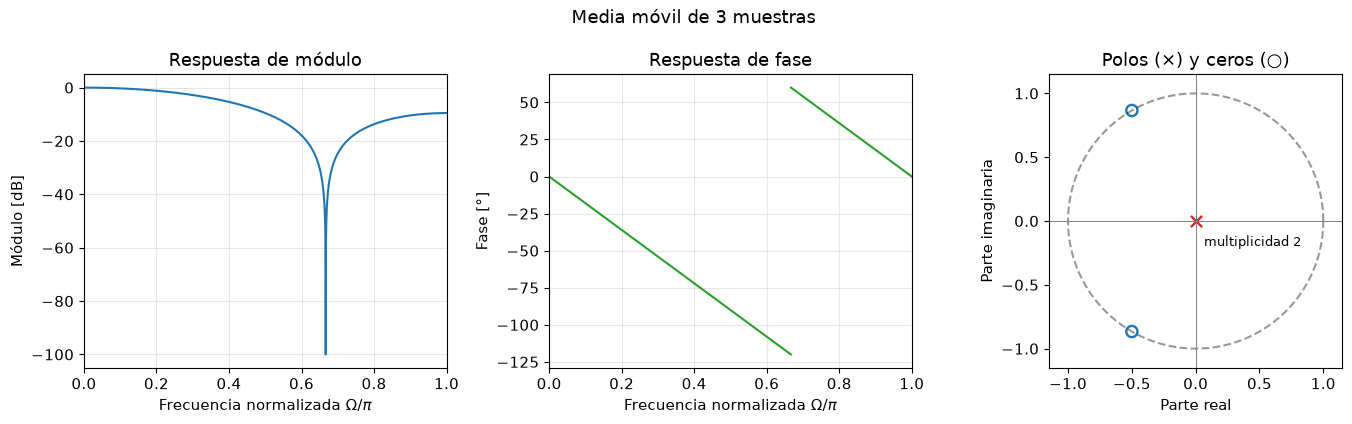

N=4: h[n]=[0.25 0.25 0.25 0.25]; error máximo=2.220e-15


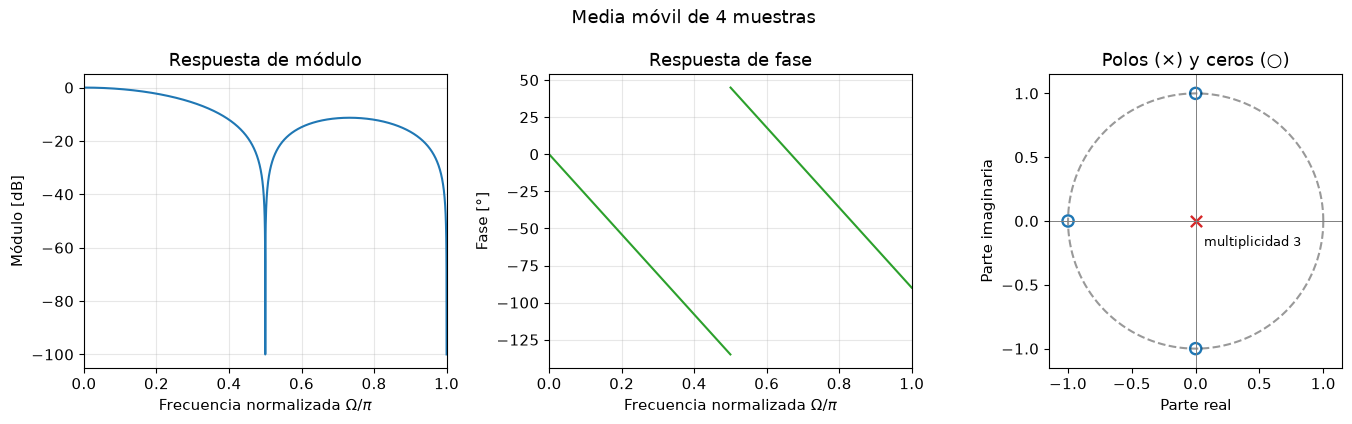

N=5: h[n]=[0.2 0.2 0.2 0.2 0.2]; error máximo=4.441e-16


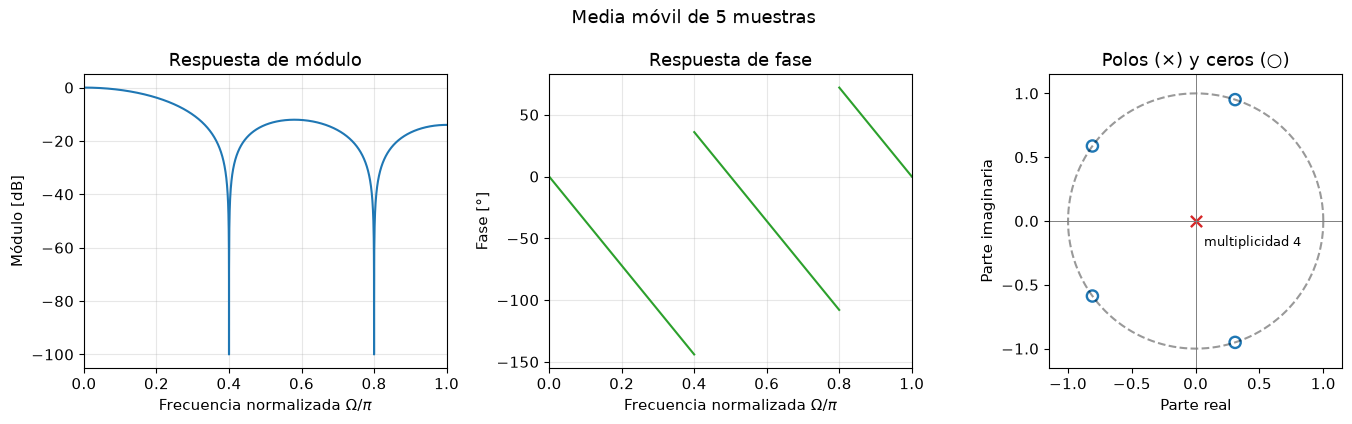

In [6]:
impulso = np.r_[1.0, np.zeros(31)]
rng = np.random.default_rng(2026)
x_prueba = rng.standard_normal(1024)

for N in [3, 4, 5]:
    num = np.ones(N)/N
    den = [1.0]
    ceros = np.exp(2j*np.pi*np.arange(1, N)/N)
    polos = np.zeros(N-1)

    h_esquema = filtrar_esquema(impulso, N=N, c1=1, a1=1, b0=1/N)
    np.testing.assert_allclose(h_esquema, np.r_[num, np.zeros(32-N)], atol=1e-14)
    y_esquema = filtrar_esquema(x_prueba, N=N, c1=1, a1=1, b0=1/N)
    y_fir = sig.lfilter(num, den, x_prueba)
    np.testing.assert_allclose(y_esquema, y_fir, atol=1e-12, rtol=0)

    print(f'N={N}: h[n]={num}; error máximo={np.max(np.abs(y_esquema-y_fir)):.3e}')
    graficar_filtro(num, den, ceros, polos, f'Media móvil de {N} muestras')

Los resultados verifican la transferencia obtenida analíticamente. La ganancia en continua es unitaria y los nulos coinciden con las posiciones de los ceros sobre la circunferencia unitaria.

## <ins>Implementación de $h[n]=(1,1,1,1,1,1,1)$</ins>

Considerando que el primer elemento corresponde a $n=0$, la respuesta impulsional es:

$$h[n]=\sum_{k=0}^{6}\delta[n-k]$$

Su transformada Z resulta:

$$H(z)=1+z^{-1}+z^{-2}+z^{-3}+z^{-4}+z^{-5}+z^{-6}$$

Utilizando la suma geométrica:

$$\boxed{H(z)=\frac{1-z^{-7}}{1-z^{-1}}}$$

Esta expresión puede implementarse con la misma topología, utilizando:

$$\boxed{N=7,\qquad c_1=1,\qquad a_0=1,\qquad a_1=1,\qquad b_0=1}$$

$$a_2=b_1=b_2=0$$

Se utiliza $b_0=1$ porque se busca sumar las siete muestras. Con $b_0=1/7$, se obtendría su promedio.

La ecuación temporal queda:

$$y[n]=\sum_{k=0}^{6}x[n-k]$$

O, mediante su implementación recursiva:

$$\boxed{y[n]=y[n-1]+x[n]-x[n-7]}$$



### Polos y ceros

El sistema es FIR de orden $6$, con seis polos en el origen. Sus ceros son:

$$z_k=1\angle\left(\frac{360^\circ k}{7}\right),\qquad k=1,\ldots,6$$

Sus posiciones aproximadas son:

$$\boxed{\begin{aligned}
z_1&=1\angle51{,}43^\circ,&z_2&=1\angle102{,}86^\circ\\
z_3&=1\angle154{,}29^\circ,&z_4&=1\angle205{,}71^\circ\\
z_5&=1\angle257{,}14^\circ,&z_6&=1\angle308{,}57^\circ
\end{aligned}}$$

### Módulo y fase

Se utiliza la expresión obtenida para la media móvil, tomando $N=7$ y eliminando la normalización $1/N$:

$$\boxed{H(e^{j\Omega})=e^{-j3\Omega}\frac{\sin(7\Omega/2)}{\sin(\Omega/2)}}$$

Por lo tanto:

$$\boxed{|H(e^{j\Omega})|=\left|\frac{\sin(7\Omega/2)}{\sin(\Omega/2)}\right|}$$

En continua:

$$H(e^{j0})=\lim_{\Omega\to0}\frac{\sin(7\Omega/2)}{\sin(\Omega/2)}=7$$

Las frecuencias de anulación entre $0$ y $\pi$ son:

$$\boxed{\Omega=\frac{2\pi}{7},\quad\frac{4\pi}{7},\quad\frac{6\pi}{7}}$$

Definiendo $B(\Omega)=\sin(7\Omega/2)/\sin(\Omega/2)$, la fase en grados resulta:

$$\boxed{\phi_{\mathrm{grados}}(\Omega)=-3\Omega\frac{180^\circ}{\pi}+\begin{cases}0^\circ,&B(\Omega)>0\\180^\circ,&B(\Omega)<0\end{cases}\quad(\bmod\,360^\circ)}$$

El retardo de grupo es de $3$ muestras. Este filtro posee la misma fase y las mismas frecuencias de anulación que una media móvil de siete muestras, pero su módulo es siete veces mayor.

Respuesta al impulso: [1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]
Ganancia en continua: 7.0


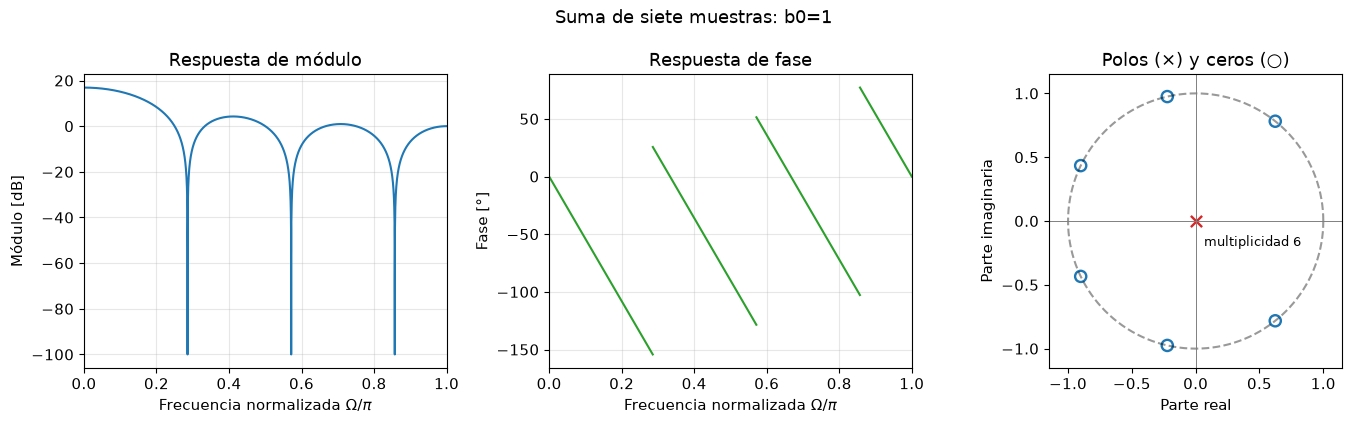

In [7]:
N = 7
num = np.ones(N)
den = [1.0]
h_7 = filtrar_esquema(impulso, N=N, c1=1, a1=1, b0=1)

np.testing.assert_array_equal(h_7, np.r_[np.ones(7), np.zeros(25)])
print('Respuesta al impulso:', h_7[:10])
print('Ganancia en continua:', np.sum(num))

graficar_filtro(num, den,
                np.exp(2j*np.pi*np.arange(1, N)/N), np.zeros(N-1),
                'Suma de siete muestras: b0=1')

---
# 3) Filtro diferenciador

## <ins>Obtención de los coeficientes</ins>

Se busca implementar la siguiente ecuación:

$$y[n]=\frac{x[n]-x[n-2]}{2}$$

Aplicando la transformada Z, con condiciones iniciales nulas:

$$Y(z)=\frac{1}{2}X(z)-\frac{1}{2}z^{-2}X(z)$$

Extrayendo factor común y dividiendo por $X(z)$:

$$\boxed{H(z)=\frac{Y(z)}{X(z)}=\frac{1}{2}-\frac{1}{2}z^{-2}}$$

Se compara esta expresión con la transferencia general:

$$H(z)=(1-c_1z^{-N})\frac{b_0+b_1z^{-1}+b_2z^{-2}}{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}$$

Se adopta $c_1=0$ para que la etapa peine tenga transferencia unitaria. Además, se utilizan $a_0=1$ y $a_1=a_2=0$, de manera que el denominador sea igual a $1$.

Entonces:

$$H(z)=b_0+b_1z^{-1}+b_2z^{-2}$$

Comparando término a término, se obtienen los coeficientes:

$$\boxed{a_0=1,\qquad b_0=\frac{1}{2},\qquad b_2=-\frac{1}{2}}$$

$$\boxed{a_1=a_2=b_1=c_1=0}$$

El valor de $N$ no afecta esta configuración, ya que la rama retardada del peine queda multiplicada por cero.

## <ins>Respuesta al impulso</ins>

Se aplica la transformada Z inversa a la transferencia:

$$H(z)=\frac{1}{2}-\frac{1}{2}z^{-2}$$

Utilizando $z^{-k}\longleftrightarrow\delta[n-k]$:

$$\boxed{h[n]=\frac{1}{2}\delta[n]-\frac{1}{2}\delta[n-2]}$$

La secuencia, comenzando en $n=0$, es:

$$h[n]=\left(\frac{1}{2},\ 0,\ -\frac{1}{2}\right)$$

La respuesta al impulso tiene duración finita y el máximo retardo es de dos muestras. Por lo tanto, el sistema es **FIR de orden 2**.

## <ins>Diagrama en bloques</ins>

La entrada se divide en dos ramas: una directa, multiplicada por $1/2$, y otra con dos retardos consecutivos, multiplicada por $-1/2$. Ambas contribuciones se suman:

<div align="center">
    <img src="./Imagenes/punto_3_bloques.png" alt="Diferenciador de dos demoras" width="1050"/>
</div>

Esta conexión reproduce:

$$y[n]=\frac{1}{2}x[n]-\frac{1}{2}x[n-2]$$

## <ins>Polos y ceros</ins>

Se expresa la transferencia con potencias positivas de $z$:

$$H(z)=\frac{1}{2}(1-z^{-2})=\frac{z^2-1}{2z^2}$$

Factorizando el numerador:

$$\boxed{H(z)=\frac{(z-1)(z+1)}{2z^2}}$$

Los ceros se obtienen haciendo cero el numerador:

$$ (z-1)(z+1)=0 $$

Por lo tanto, sus posiciones en forma polar son:

$$\boxed{z_1=1\angle0^\circ,\qquad z_2=1\angle180^\circ}$$

El denominador presenta dos polos en el origen:

$$\boxed{z_p=0\quad\text{con multiplicidad }2}$$

El cero en $z=1$ anula la componente continua, mientras que el cero en $z=-1$ anula la frecuencia de Nyquist.

## <ins>Respuesta de módulo y fase</ins>

Se evalúa la transferencia sobre el círculo unitario, reemplazando $z=e^{j\Omega}$:

$$H(e^{j\Omega})=\frac{1}{2}(1-e^{-j2\Omega})$$

Extrayendo el factor $e^{-j\Omega}$:

$$H(e^{j\Omega})=\frac{1}{2}e^{-j\Omega}\left(e^{j\Omega}-e^{-j\Omega}\right)$$

Utilizando $e^{j\Omega}-e^{-j\Omega}=2j\sin\Omega$:

$$\boxed{H(e^{j\Omega})=j\,e^{-j\Omega}\sin\Omega}$$

### Módulo

Los factores $j$ y $e^{-j\Omega}$ tienen módulo unitario. Entonces:

$$\boxed{|H(e^{j\Omega})|=|\sin\Omega|}$$

La respuesta se anula en $\Omega=0$ y $\Omega=\pi$, y alcanza un módulo máximo de $1$ en $\Omega=\pi/2$.

Para frecuencias bajas:

$$\sin\Omega\approx\Omega$$

Por lo tanto:

$$H(e^{j\Omega})\approx j\Omega e^{-j\Omega}$$

El factor $j\Omega$ corresponde a un diferenciador ideal respecto del índice de muestra, mientras que $e^{-j\Omega}$ introduce un retardo de una muestra. Esto permite identificar al sistema como un aproximador de derivada para bajas frecuencias.

### Fase y retardo de grupo

En el intervalo $0<\Omega<\pi$, el factor $\sin\Omega$ es positivo y no aporta fase. El factor $j$ aporta $\pi/2$, mientras que el factor exponencial aporta $-\Omega$:

$$\phi_{\mathrm{rad}}(\Omega)=\frac{\pi}{2}-\Omega$$

Expresando la fase en grados:

$$\boxed{\phi_{\mathrm{grados}}(\Omega)=90^\circ-\Omega\frac{180^\circ}{\pi},\qquad 0<\Omega<\pi}$$

En continua y Nyquist, la fase no está definida porque el módulo es nulo.

El retardo de grupo se calcula utilizando la fase en radianes:

$$\tau_g=-\frac{d\phi_{\mathrm{rad}}}{d\Omega}=-\frac{d}{d\Omega}\left(\frac{\pi}{2}-\Omega\right)$$

$$\boxed{\tau_g=1\ \text{muestra}}$$

### Representación en Python

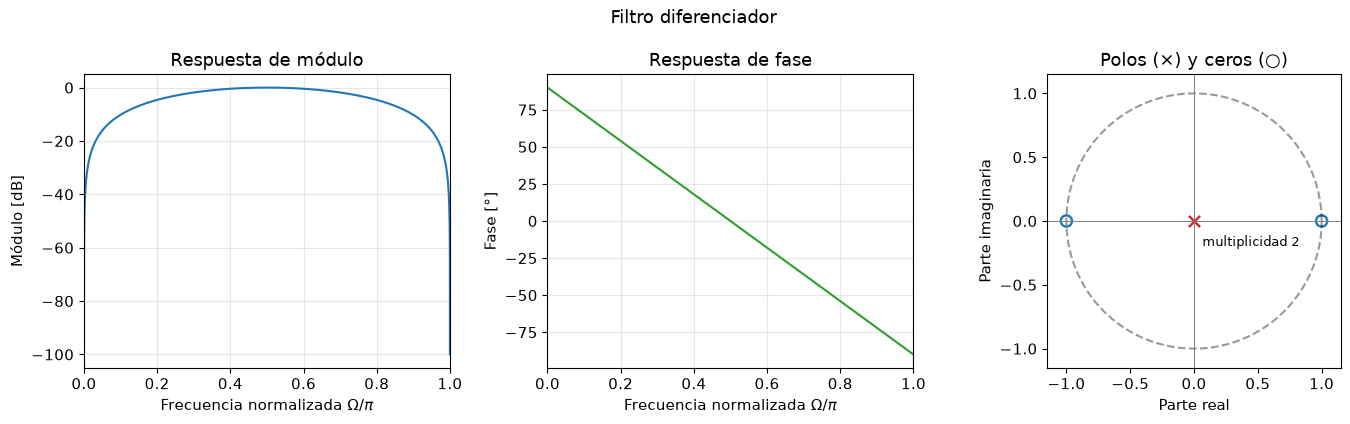

In [8]:
num_dif = np.array([0.5, 0.0, -0.5])
den_dif = [1.0]
h_dif = filtrar_esquema(impulso, b0=0.5, b2=-0.5)
np.testing.assert_array_equal(h_dif, np.r_[num_dif, np.zeros(29)])

graficar_filtro(num_dif, den_dif, [1, -1], [0, 0], 'Filtro diferenciador')

## <ins>Evaluación con una señal senoidal</ins>

Se considera la entrada:

$$x[n]=\sin(\Omega_0n)$$

Reemplazando en la ecuación del filtro:

$$y[n]=\frac{\sin(\Omega_0n)-\sin(\Omega_0(n-2))}{2}$$

Se utiliza la identidad:

$$\sin A-\sin B=2\cos\left(\frac{A+B}{2}\right)\sin\left(\frac{A-B}{2}\right)$$

En este caso:

$$\frac{A+B}{2}=\Omega_0(n-1),\qquad\frac{A-B}{2}=\Omega_0$$

Entonces:

$$\boxed{y[n]=\sin(\Omega_0)\cos\left(\Omega_0(n-1)\right)}$$

Para comparar con una derivada respecto del tiempo, se divide la salida por el intervalo de muestreo $T_s$:

$$\frac{y[n]}{T_s}=\frac{\sin\Omega_0}{T_s}\cos\left(\Omega_0(n-1)\right)$$

La derivada ideal de la señal senoidal, evaluada una muestra antes, es:

$$x'_{\mathrm{ref}}[n]=\frac{\Omega_0}{T_s}\cos\left(\Omega_0(n-1)\right)$$

Por lo tanto:

$$\boxed{\frac{y[n]}{T_s}\approx x'\left((n-1)T_s\right)}$$

La aproximación depende de que $\sin\Omega_0\approx\Omega_0$, y la relación entre amplitudes resulta:

$$\boxed{\frac{A_{\mathrm{filtro}/T_s}}{A_{\mathrm{referencia}}}=\frac{\sin\Omega_0}{\Omega_0}}$$

## <ins>Verificación con `scipy.fftpack.diff`</ins>

Se utiliza `scipy.fftpack.diff` para obtener la derivada de referencia mediante Fourier.

Se adoptan:

$$f_s=200\ \text{Hz},\qquad f_0=5\ \text{Hz},\qquad M=80\ \text{muestras}$$

El registro tiene una duración de:

$$T_{\mathrm{registro}}=\frac{M}{f_s}=0{,}4\ \text{s}$$

Este intervalo contiene exactamente dos períodos de la señal. Se utiliza `period=M*Ts`, sin repetir la muestra del extremo final.

Para comparar ambas derivadas, se retarda una muestra la referencia y se excluyen las primeras dos muestras de salida, correspondientes al arranque del filtro.

Error de amplitud: 0.4107 %


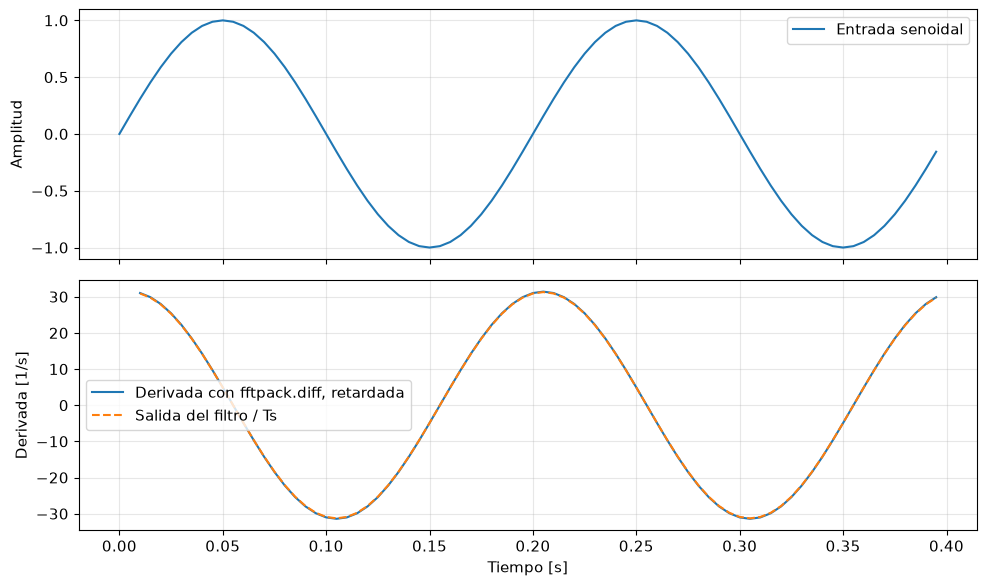

In [9]:
# Parámetros de la señal
fs_dif = 200.0
f0_dif = 5.0
Ts_dif = 1 / fs_dif
M = 80
n_seno = np.arange(M)
t_seno = n_seno * Ts_dif
x_seno = np.sin(2 * np.pi * f0_dif * t_seno)

# Salida del filtro y conversión a derivada temporal
y_seno = sig.lfilter(num_dif, den_dif, x_seno)
np.testing.assert_allclose(
    y_seno, filtrar_esquema(x_seno, b0=0.5, b2=-0.5), atol=1e-14
)
derivada_filtro = y_seno / Ts_dif

# Derivada de referencia mediante Fourier
derivada_diff = diff(x_seno, order=1, period=M * Ts_dif)
derivada_diff_retardada = np.roll(derivada_diff, 1)

# Verificación con la derivada analítica
derivada_analitica = 2 * np.pi * f0_dif * np.cos(2 * np.pi * f0_dif * t_seno)
np.testing.assert_allclose(
    derivada_diff, derivada_analitica, atol=1e-10, rtol=0
)

# Se excluye el arranque con condiciones iniciales nulas
validas = slice(2, None)
omega0 = 2 * np.pi * f0_dif / fs_dif
relacion_amplitudes = np.sin(omega0) / omega0
np.testing.assert_allclose(
    derivada_filtro[validas],
    relacion_amplitudes * derivada_diff_retardada[validas],
    atol=1e-10, rtol=0
)
error_amplitud = 100 * (1 - relacion_amplitudes)
print(f"Error de amplitud: {error_amplitud:.4f} %")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_seno, x_seno, label="Entrada senoidal")
axes[0].set_ylabel("Amplitud")
axes[0].legend()
axes[1].plot(t_seno[validas], derivada_diff_retardada[validas],
             label="Derivada con fftpack.diff, retardada")
axes[1].plot(t_seno[validas], derivada_filtro[validas], "--",
             label="Salida del filtro / Ts")
axes[1].set_xlabel("Tiempo [s]")
axes[1].set_ylabel("Derivada [1/s]")
axes[1].legend()
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Para los valores adoptados:

$$\Omega_0=2\pi\frac{f_0}{f_s}=0{,}05\pi$$

El error relativo de amplitud es:

$$\varepsilon_A=\left(1-\frac{\sin\Omega_0}{\Omega_0}\right)100$$

$$\boxed{\varepsilon_A\approx0{,}4107\%}$$

La salida del filtro aproxima la derivada de la señal senoidal, considerando la escala $1/T_s$ y el retardo de una muestra. La diferencia de amplitud aumenta con la frecuencia debido a que $\sin\Omega_0$ se aleja de $\Omega_0$.

---
# 4) Filtro elimina continua

## <ins>Obtención de la transferencia</ins>

Se parte de la transferencia general:

$$H(z)=(1-c_1z^{-N})\frac{b_0+b_1z^{-1}+b_2z^{-2}}{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}$$

Se reemplazan los coeficientes indicados:

$$a_0=1,\qquad a_1=\beta,\qquad b_0=1,\qquad b_1=-1$$

Los coeficientes restantes se consideran nulos:

$$a_2=b_2=c_1=0$$

Entonces:

$$\boxed{H(z)=\frac{1-z^{-1}}{1-\beta z^{-1}}}$$

Para $\beta=0{,}9$:

$$\boxed{H(z)=\frac{1-z^{-1}}{1-0{,}9z^{-1}}}$$

## <ins>Ecuación temporal y diagrama en bloques</ins>

Se parte de:

$$\frac{Y(z)}{X(z)}=\frac{1-z^{-1}}{1-\beta z^{-1}}$$

Multiplicando y distribuyendo:

$$ (1-\beta z^{-1})Y(z)=(1-z^{-1})X(z) $$

$$Y(z)-\beta z^{-1}Y(z)=X(z)-z^{-1}X(z)$$

Aplicando la transformada Z inversa y despejando:

$$\boxed{y[n]=x[n]-x[n-1]+\beta y[n-1]}$$

La salida combina la diferencia entre dos muestras consecutivas de entrada con una fracción de la salida anterior.

En la topología del enunciado, las señales internas cumplen:

$$w[n]=x[n]+\beta w[n-1]$$

$$y[n]=w[n]-w[n-1]$$

El diagrama equivalente queda:

<div align="center">
    <img src="./Imagenes/punto_4_bloques.png" alt="Filtro elimina continua" width="1100"/>
</div>

Se utiliza una sola demora del biquad; las ramas correspondientes a $a_2$ y $b_2$ quedan anuladas.

## <ins>Polos y ceros</ins>

Se expresa la transferencia con potencias positivas de $z$:

$$H(z)=\frac{z-1}{z-\beta}$$

El cero se obtiene haciendo cero el numerador:

$$z-1=0\quad\Rightarrow\quad\boxed{z_c=1=1\angle0^\circ}$$

El polo se obtiene del denominador:

$$z-\beta=0\quad\Rightarrow\quad\boxed{z_p=\beta}$$

Para $\beta=0{,}9$, su posición en forma polar es:

$$\boxed{z_p=0{,}9\angle0^\circ}$$

El polo se encuentra dentro del círculo unitario. En general, el sistema causal es estable si:

$$\boxed{|\beta|<1}$$

## <ins>Respuesta al impulso</ins>

Se reescribe la transferencia:

$$H(z)=\frac{(1-\beta z^{-1})+(\beta-1)z^{-1}}{1-\beta z^{-1}}$$

Separando los términos:

$$H(z)=1+(\beta-1)\frac{z^{-1}}{1-\beta z^{-1}}$$

Para la realización causal:

$$\frac{z^{-1}}{1-\beta z^{-1}}\longleftrightarrow\beta^{n-1}u[n-1]$$

Por lo tanto:

$$h[n]=\delta[n]+(\beta-1)\beta^{n-1}u[n-1]$$

O bien:

$$\boxed{h[n]=\begin{cases}1,&n=0\\(\beta-1)\beta^{n-1},&n\geq1\\0,&n<0\end{cases}}$$

Para $\beta=0{,}9$, las primeras muestras son:

$$h[n]=(1,\,-0{,}1,\,-0{,}09,\,-0{,}081,\ldots)$$

La respuesta continúa indefinidamente, aunque su amplitud decrece. Por lo tanto, se trata de un **IIR de primer orden**.


## <ins>Respuesta de módulo y fase</ins>

Se evalúa la transferencia en $z=e^{j\Omega}$:

$$H(e^{j\Omega})=\frac{1-e^{-j\Omega}}{1-\beta e^{-j\Omega}}$$

### Módulo

Para calcular el módulo, se multiplica cada expresión por su conjugado:

$$|1-e^{-j\Omega}|^2=(1-e^{-j\Omega})(1-e^{j\Omega})$$

$$|1-e^{-j\Omega}|^2=2-2\cos\Omega$$

Para el denominador:

$$|1-\beta e^{-j\Omega}|^2=(1-\beta e^{-j\Omega})(1-\beta e^{j\Omega})$$

$$|1-\beta e^{-j\Omega}|^2=1+\beta^2-2\beta\cos\Omega$$

Por lo tanto:

$$\boxed{|H(e^{j\Omega})|=\sqrt{\frac{2-2\cos\Omega}{1+\beta^2-2\beta\cos\Omega}}}$$

En Nyquist, $\Omega=\pi$ y $\cos\pi=-1$:

$$|H(e^{j\pi})|=\sqrt{\frac{4}{(1+\beta)^2}}$$

Para los valores positivos de $\beta$ considerados:

$$\boxed{|H(e^{j\pi})|=\frac{2}{1+\beta}}$$

Con $\beta=0{,}9$:

$$|H(e^{j\pi})|=\frac{2}{1{,}9}\approx1{,}05263$$

La ganancia en Nyquist no es exactamente unitaria, por lo que debe utilizarse como referencia al calcular la atenuación solicitada.

### Fase

Para el numerador se utiliza:

$$1-e^{-j\Omega}=2j\,e^{-j\Omega/2}\sin\left(\frac{\Omega}{2}\right)$$

En $0<\Omega\leq\pi$, el seno es positivo. Entonces:

$$\arg(1-e^{-j\Omega})=\frac{\pi}{2}-\frac{\Omega}{2}$$

El denominador se escribe como:

$$1-\beta e^{-j\Omega}=(1-\beta\cos\Omega)+j\beta\sin\Omega$$

Para $0<\beta<1$, su parte real es positiva, de modo que:

$$\arg(1-\beta e^{-j\Omega})=\arctan\left(\frac{\beta\sin\Omega}{1-\beta\cos\Omega}\right)$$

La fase de un cociente es la diferencia de las fases:

$$\phi_{\mathrm{rad}}(\Omega)=\frac{\pi}{2}-\frac{\Omega}{2}-\arctan\left(\frac{\beta\sin\Omega}{1-\beta\cos\Omega}\right)$$

Expresada en grados:

$$\boxed{\phi_{\mathrm{grados}}(\Omega)=\left[\frac{\pi}{2}-\frac{\Omega}{2}-\arctan\left(\frac{\beta\sin\Omega}{1-\beta\cos\Omega}\right)\right]\frac{180^\circ}{\pi}}$$

En continua la fase no está definida, ya que el módulo es cero.

### Verificación para $\beta=0{,}9$

Se representan el módulo, la fase en grados y las singularidades. En el gráfico de módulo se utiliza un límite inferior de $-100\ \mathrm{dB}$ para representar el cero en continua, cuyo valor ideal es $-\infty\ \mathrm{dB}$.

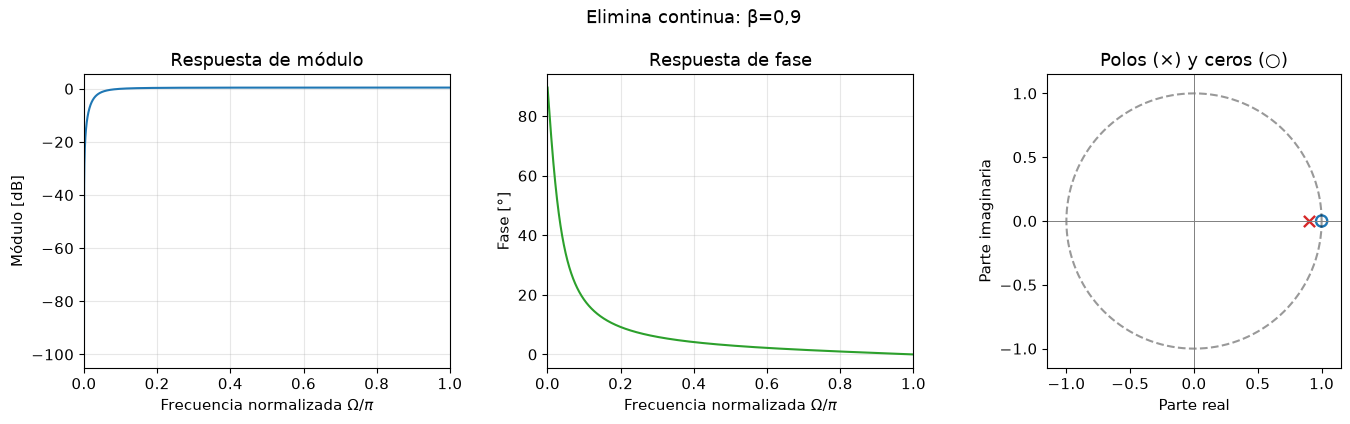

✓ Se verifica la respuesta al impulso del IIR.


In [10]:
beta_inicial = 0.9
num_dc = [1.0, -1.0]
den_dc = [1.0, -beta_inicial]
graficar_filtro(num_dc, den_dc, [1], [beta_inicial], 'Elimina continua: β=0,9')

n_dc = np.arange(80)
h_dc = filtrar_esquema(np.r_[1.0, np.zeros(79)], a1=beta_inicial, b1=-1)
h_dc_teorica = np.r_[1.0, (beta_inicial-1)*beta_inicial**np.arange(79)]
np.testing.assert_allclose(h_dc, h_dc_teorica, atol=1e-14, rtol=0)
print('✓ Se verifica la respuesta al impulso del IIR.')

## <ins>Determinación de $\beta$</ins>

Se pide que el módulo en $\Omega_c=0{,}1\pi$ sea $3\ \mathrm{dB}$ menor que en $\Omega=\pi$:

$$20\log_{10}\left(\frac{|H(e^{j\Omega_c})|}{|H(e^{j\pi})|}\right)=-3$$

Despejando la relación de módulos y elevando al cuadrado:

$$\frac{|H(e^{j\Omega_c})|^2}{|H(e^{j\pi})|^2}=10^{-3/10}$$

Se define:

$$q=10^{-3/10},\qquad c=\cos\Omega_c$$

Reemplazando las expresiones de módulo:

$$\frac{2-2c}{1+\beta^2-2\beta c}\frac{(1+\beta)^2}{4}=q$$

Como $2-2c=2(1-c)$:

$$ (1-c)(1+\beta)^2=2q(1+\beta^2-2\beta c) $$

Desarrollando los productos y agrupando:

$$\boxed{[2q-(1-c)]\beta^2-[4qc+2(1-c)]\beta+[2q-(1-c)]=0}$$

Para $\Omega_c=0{,}1\pi$:

$$q\approx0{,}501187,\qquad c\approx0{,}951057$$

Resolviendo la ecuación cuadrática:

$$\beta_1\approx0{,}72710258,\qquad\beta_2\approx1{,}37532176$$

Se selecciona la raíz que cumple la condición de estabilidad $|\beta|<1$:

$$\boxed{\beta=0{,}72710258}$$

### Verificación en Python

Se calcula $\beta$ y se verifica la diferencia de $3\ \mathrm{dB}$ respecto de la ganancia en Nyquist.

In [11]:
omega_c = 0.1*np.pi
q = 10**(-3/10)
c = np.cos(omega_c)
A = 2*q-(1-c)
B = -(4*q*c+2*(1-c))
raices_beta = np.roots([A, B, A])
beta_final = float(raices_beta[np.abs(raices_beta) < 1][0])

print('Raíces de la ecuación:', raices_beta)
print(f'β estable = {beta_final:.12f}')

resultados_dc = []
for beta_val in [beta_inicial, beta_final]:
    _, H_eval = sig.freqz([1, -1], [1, -beta_val], worN=[0, omega_c, np.pi])
    caida = 20*np.log10(abs(H_eval[1])/abs(H_eval[2]))
    resultados_dc.append([beta_val, abs(H_eval[0]), abs(H_eval[1]), abs(H_eval[2]), caida])
    if beta_val == beta_final:
        np.testing.assert_allclose(caida, -3, atol=1e-12)

display(pd.DataFrame(resultados_dc,
                     columns=['β', '|H(0)|', '|H(0,1π)|', '|H(π)|', 'Caída relativa [dB]']))

Raíces de la ecuación: [1.37532176 0.72710258]
β estable = 0.727102581389


,β,|H(0)|,"|H(0,1π)|",|H(π)|,Caída relativa [dB]
0,0.900000,0.0,0.998922,1.052632,-0.454893
1,0.727103,0.0,0.819807,1.158009,-3.000000


La transferencia resultante es:

$$\boxed{H(z)=\frac{1-z^{-1}}{1-0{,}72710258z^{-1}}}$$

El cero permanece en $1\angle0^\circ$ y el polo se ubica en:

$$z_p=0{,}72710258\angle0^\circ$$

Se representan las singularidades y la respuesta en frecuencia del filtro diseñado. Además, se compara la atenuación relativa a Nyquist y la respuesta a una entrada constante de ambas configuraciones.

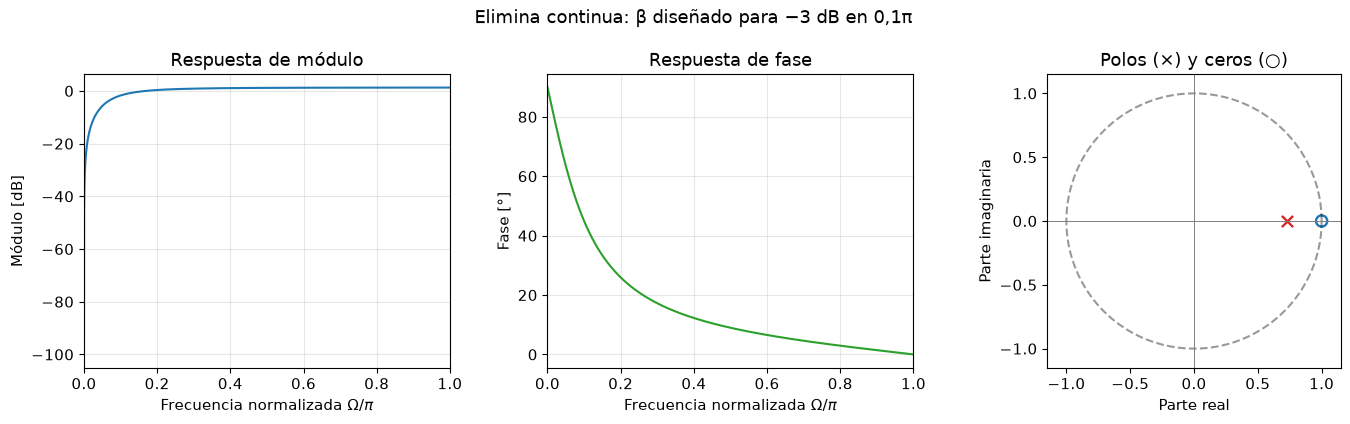

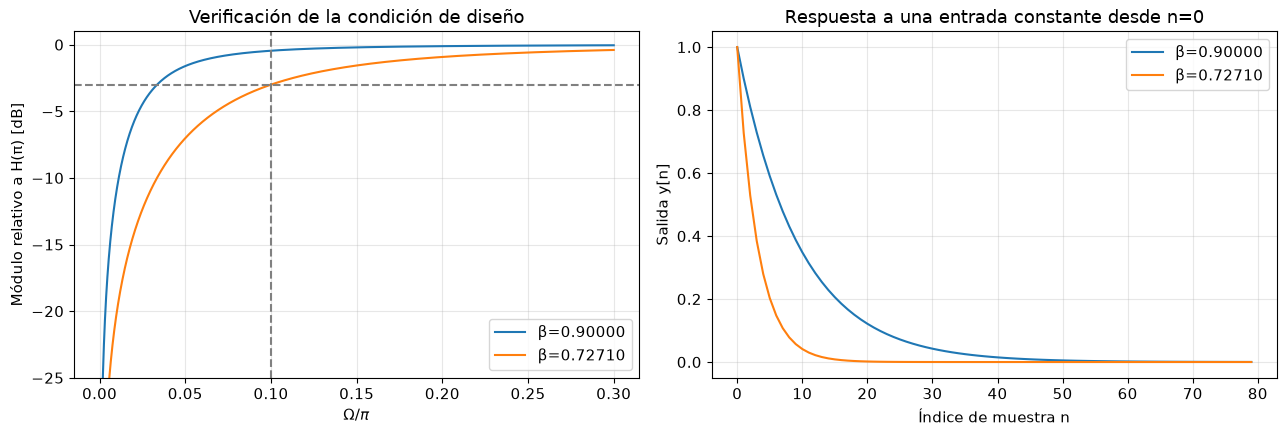

In [12]:
graficar_filtro([1, -1], [1, -beta_final], [1], [beta_final],
                'Elimina continua: β diseñado para −3 dB en 0,1π')

omega_dc = np.unique(np.r_[np.linspace(1e-4, 0.3*np.pi, 3000), omega_c])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for beta_val in [beta_inicial, beta_final]:
    _, H = sig.freqz([1, -1], [1, -beta_val], worN=omega_dc)
    H_pi = 2/(1+beta_val)
    axes[0].plot(omega_dc/np.pi, 20*np.log10(abs(H)/H_pi), label=f'β={beta_val:.5f}')
    salida = filtrar_esquema(np.ones(80), a1=beta_val, b1=-1)
    np.testing.assert_allclose(salida, beta_val**n_dc, atol=1e-13, rtol=0)
    axes[1].plot(n_dc, salida, label=f'β={beta_val:.5f}')

axes[0].axhline(-3, color='gray', ls='--')
axes[0].axvline(0.1, color='gray', ls='--')
axes[0].set(xlabel=r'$\Omega/\pi$', ylabel='Módulo relativo a H(π) [dB]',
             title='Verificación de la condición de diseño', ylim=(-25, 1))
axes[1].set(xlabel='Índice de muestra n', ylabel='Salida y[n]',
             title='Respuesta a una entrada constante desde n=0')
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()

Para el valor calculado:

$$|H(e^{j0{,}1\pi})|\approx0{,}819807$$

$$|H(e^{j\pi})|\approx1{,}158009$$

Entonces:

$$\boxed{20\log_{10}\left(\frac{0{,}819807}{1{,}158009}\right)\approx-3\ \mathrm{dB}}$$

Se verifica que el filtro elimina la componente continua y cumple la atenuación solicitada respecto de la ganancia en Nyquist.

---
# 5) Filtro peine

## <ins>Obtención de la transferencia</ins>

Se parte de la transferencia general:

$$H(z)=(1-c_1z^{-N})\frac{b_0+b_1z^{-1}+b_2z^{-2}}{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}$$

Se adoptan los valores indicados:

$$c_1=-1,\qquad N=8$$

Para analizar la etapa peine, se configura el biquad con transferencia unitaria:

$$a_0=b_0=1,\qquad a_1=a_2=b_1=b_2=0$$

Estos dos coeficientes unitarios permiten que la señal atraviese el biquad. Si se anularan todos sus coeficientes, la salida sería nula.

Reemplazando:

$$H(z)=\left(1-(-1)z^{-8}\right)\frac{1}{1}$$

$$\boxed{H(z)=1+z^{-8}}$$

## <ins>Ecuación temporal y diagrama en bloques</ins>

Como $Y(z)=H(z)X(z)$:

$$Y(z)=X(z)+z^{-8}X(z)$$

Aplicando la transformada Z inversa:

$$\boxed{y[n]=x[n]+x[n-8]}$$

La salida es la suma de la muestra actual y una copia retardada ocho muestras:

<div align="center">
    <img src="./Imagenes/punto_5_bloques.png" alt="Filtro peine con suma" width="1050"/>
</div>

En el esquema original, la rama retardada se multiplica por $c_1=-1$ y luego se resta en el sumador. Por lo tanto, su contribución final es positiva.

## <ins>Respuesta al impulso</ins>

Se aplica la transformada Z inversa a:

$$H(z)=1+z^{-8}$$

Utilizando $z^{-k}\longleftrightarrow\delta[n-k]$:

$$\boxed{h[n]=\delta[n]+\delta[n-8]}$$

La secuencia, comenzando en $n=0$, es:

$$\boxed{h[n]=(1,0,0,0,0,0,0,0,1)}$$

La respuesta tiene duración finita y su máximo retardo es de ocho muestras. Por lo tanto, corresponde a un **FIR de orden 8**.

## <ins>Polos y ceros</ins>

Se expresa la transferencia con potencias positivas de $z$:

$$H(z)=\frac{z^8+1}{z^8}$$

El denominador presenta ocho polos en el origen:

$$\boxed{z_p=0\quad\text{con multiplicidad }8}$$

Los ceros se obtienen haciendo cero el numerador:

$$z^8+1=0\quad\Rightarrow\quad z^8=-1$$

Se expresa $-1$ en forma polar:

$$-1=e^{j(\pi+2k\pi)}$$

Tomando las ocho raíces:

$$z_k=e^{j(2k+1)\pi/8},\qquad k=0,\ldots,7$$

Por lo tanto, todos los ceros tienen módulo $1$ y sus ángulos son:

$$\boxed{\theta_k=\frac{(2k+1)180^\circ}{8}=22{,}5^\circ+45^\circ k}$$

| Cero | Posición en forma polar |
|---|---|
| $z_0$ | $1\angle22{,}5^\circ$ |
| $z_1$ | $1\angle67{,}5^\circ$ |
| $z_2$ | $1\angle112{,}5^\circ$ |
| $z_3$ | $1\angle157{,}5^\circ$ |
| $z_4$ | $1\angle202{,}5^\circ$ |
| $z_5$ | $1\angle247{,}5^\circ$ |
| $z_6$ | $1\angle292{,}5^\circ$ |
| $z_7$ | $1\angle337{,}5^\circ$ |

Los ceros se distribuyen uniformemente sobre el círculo unitario, separados $45^\circ$.

## <ins>Respuesta de módulo y fase</ins>

Se evalúa la transferencia en $z=e^{j\Omega}$:

$$H(e^{j\Omega})=1+e^{-j8\Omega}$$

Extrayendo el factor $e^{-j4\Omega}$:

$$H(e^{j\Omega})=e^{-j4\Omega}\left(e^{j4\Omega}+e^{-j4\Omega}\right)$$

Utilizando $e^{j\theta}+e^{-j\theta}=2\cos\theta$:

$$\boxed{H(e^{j\Omega})=2e^{-j4\Omega}\cos(4\Omega)}$$

### Módulo

Como el factor exponencial tiene módulo unitario:

$$\boxed{|H(e^{j\Omega})|=2|\cos(4\Omega)|}$$

El módulo alterna periódicamente entre máximos de valor $2$ y nulos. Esta repetición de picos y valles da lugar a la denominación de filtro peine.

### Fase y retardo de grupo

El factor exponencial aporta una fase $-4\Omega$. El factor real $2\cos(4\Omega)$ aporta $0$ cuando es positivo y $\pi$ cuando es negativo:

$$\phi_{\mathrm{rad}}(\Omega)=-4\Omega+\begin{cases}0,&\cos(4\Omega)>0\\\pi,&\cos(4\Omega)<0\end{cases}\quad(\bmod\,2\pi)$$

Expresando la fase en grados:

$$\boxed{\phi_{\mathrm{grados}}(\Omega)=-4\Omega\frac{180^\circ}{\pi}+\begin{cases}0^\circ,&\cos(4\Omega)>0\\180^\circ,&\cos(4\Omega)<0\end{cases}\quad(\bmod\,360^\circ)}$$

Entre las frecuencias de anulación, el término adicional es constante. Entonces:

$$\tau_g=-\frac{d\phi_{\mathrm{rad}}}{d\Omega}=-\frac{d}{d\Omega}(-4\Omega+C)$$

$$\boxed{\tau_g=4\ \text{muestras}}$$

En los nulos, la fase y el retardo de grupo no están definidos.

## <ins>Frecuencias de los picos y los nulos</ins>

Se adopta una frecuencia de muestreo:

$$\boxed{f_s=8000\ \text{Hz}}$$

La relación entre frecuencia digital y frecuencia en hertz es:

$$\Omega=2\pi\frac{f}{f_s}$$

Por lo tanto, se analiza el intervalo entre continua y Nyquist:

$$0\leq f\leq\frac{f_s}{2}=4000\ \text{Hz}$$

### Picos

El módulo alcanza su máximo cuando:

$$|\cos(4\Omega)|=1$$

Esto sucede si:

$$4\Omega=k\pi\quad\Rightarrow\quad\Omega_{\mathrm{pico}}=\frac{k\pi}{4}$$

Convirtiendo a hertz:

$$f_{\mathrm{pico}}=\frac{\Omega_{\mathrm{pico}}f_s}{2\pi}=\frac{kf_s}{8}$$

$$\boxed{f_{\mathrm{pico}}=1000k\ \text{Hz}}$$

En el intervalo considerado:

$$\boxed{f_{\mathrm{pico}}=0,\ 1000,\ 2000,\ 3000,\ 4000\ \text{Hz}}$$

En todos estos puntos:

$$|H|=2,\qquad20\log_{10}(2)\approx6{,}0206\ \mathrm{dB}$$

### Nulos

El módulo se anula cuando:

$$\cos(4\Omega)=0$$

Los ceros del coseno se encuentran en:

$$4\Omega=\frac{\pi}{2}+k\pi$$

Despejando:

$$\Omega_{\mathrm{nulo}}=\frac{(2k+1)\pi}{8}$$

Convirtiendo a hertz:

$$f_{\mathrm{nulo}}=\frac{(2k+1)f_s}{16}$$

$$\boxed{f_{\mathrm{nulo}}=500(2k+1)\ \text{Hz}}$$

En el intervalo considerado:

$$\boxed{f_{\mathrm{nulo}}=500,\ 1500,\ 2500,\ 3500\ \text{Hz}}$$

En estas frecuencias, la señal retardada llega en oposición de fase respecto de la señal directa y ambas se cancelan.

| Tipo | Frecuencias entre $0$ y $4000\ \mathrm{Hz}$ | Módulo |
|---|---|---|
| Picos | $0,\ 1000,\ 2000,\ 3000,\ 4000$ Hz | $2$ |
| Nulos | $500,\ 1500,\ 2500,\ 3500$ Hz | $0$ |

## <ins>Verificación en Python</ins>

Se representan el módulo, la fase en grados y las singularidades. Además, se verifica que las frecuencias calculadas correspondan a máximos y nulos de la transferencia.

,Frecuencia [Hz],Ω/π,Tipo,|H|
0,0.0,0.000,Máximo,2.000000e+00
1,500.0,0.125,Nulo,2.291069e-16
2,1000.0,0.250,Máximo,2.000000e+00
3,1500.0,0.375,Nulo,8.334225e-16
4,2000.0,0.500,Máximo,2.000000e+00
5,2500.0,0.625,Nulo,2.224101e-15
6,3000.0,0.750,Máximo,2.000000e+00
7,3500.0,0.875,Nulo,1.045483e-15
8,4000.0,1.000,Máximo,2.000000e+00


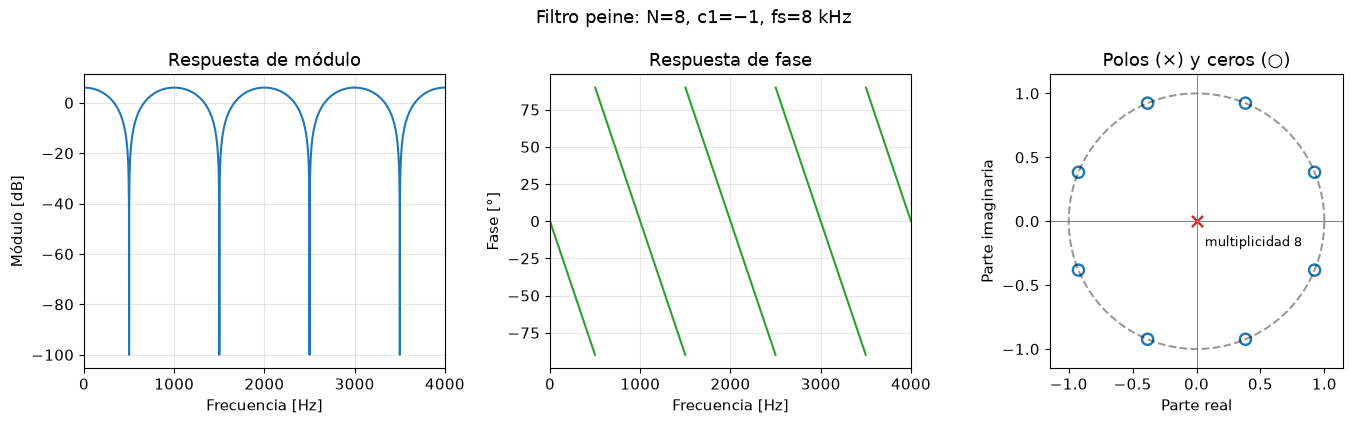

In [13]:
N_peine = 8
fs_peine = 8000.0
num_peine = np.r_[1.0, np.zeros(N_peine-1), 1.0]
den_peine = [1.0]
ceros_peine = np.exp(1j*(2*np.arange(N_peine)+1)*np.pi/N_peine)
polos_peine = np.zeros(N_peine)

picos_hz = np.arange(5)*fs_peine/N_peine
nulos_hz = (2*np.arange(4)+1)*fs_peine/(2*N_peine)
frecuencias = np.sort(np.r_[picos_hz, nulos_hz])
_, H_peine = sig.freqz(num_peine, den_peine, worN=2*np.pi*frecuencias/fs_peine)
tipo = np.where(np.isin(frecuencias, picos_hz), 'Máximo', 'Nulo')
display(pd.DataFrame({'Frecuencia [Hz]': frecuencias,
                      'Ω/π': 2*frecuencias/fs_peine,
                      'Tipo': tipo, '|H|': np.abs(H_peine)}))

np.testing.assert_allclose(H_peine[::2], 2, atol=1e-13)
np.testing.assert_allclose(H_peine[1::2], 0, atol=1e-13)
graficar_filtro(num_peine, den_peine, ceros_peine, polos_peine,
                'Filtro peine: N=8, c1=−1, fs=8 kHz', fs=fs_peine)

In [14]:
# Comprobación temporal de todos los máximos y nulos.
# Se usa coseno para incluir también continua y Nyquist.
n_peine = np.arange(1032)
for frecuencia in frecuencias:
    entrada = np.cos(2*np.pi*frecuencia*n_peine/fs_peine)
    salida = filtrar_esquema(entrada, N=8, c1=-1)
    referencia = 2*entrada[8:] if frecuencia in picos_hz else np.zeros(len(entrada)-8)
    np.testing.assert_allclose(salida[8:], referencia, atol=1e-11, rtol=0)

h_peine = filtrar_esquema(impulso, N=8, c1=-1)
np.testing.assert_array_equal(h_peine, np.r_[num_peine, np.zeros(23)])
print('✓ Se verifican el impulso y todas las frecuencias de máximos y nulos.')

✓ Se verifican el impulso y todas las frecuencias de máximos y nulos.


La respuesta presenta picos separados $1000\ \mathrm{Hz}$, con un nulo a mitad de camino entre cada par de picos consecutivos. Este comportamiento se debe a la suma constructiva o destructiva entre la señal de entrada y su copia retardada ocho muestras.

---
# Bonus 2) Pasatodo de primer orden mediante transformada bilineal

## <ins>Prototipo analógico</ins>

Se utiliza la transferencia pasatodo de primer orden analizada en el trabajo semanal 1:

$$
\boxed{H_a(s)=\frac{s-\omega_a}{s+\omega_a},\qquad\omega_a>0}
$$

El prototipo posee un cero en $s=+\omega_a$ y un polo en $s=-\omega_a$. Sobre el eje imaginario:

$$
|H_a(j\omega)|=\frac{\sqrt{\omega^2+\omega_a^2}}{\sqrt{\omega^2+\omega_a^2}}=1
$$

Su fase varía de $\pi$ a $0$ para frecuencias positivas:

$$
\varphi_a(\omega)=\pi-2\arctan\left(\frac{\omega}{\omega_a}\right)
$$

En $\omega=\omega_a$ la fase vale $\pi/2$.

## <ins>Aplicación de la transformada bilineal</ins>

Se utiliza el método:

$$
s=\frac{2}{T_s}\frac{1-z^{-1}}{1+z^{-1}}
=K\frac{1-z^{-1}}{1+z^{-1}},\qquad K=2f_s
$$

Reemplazando en el prototipo:

$$
H_d(z)=
\frac{K\dfrac{1-z^{-1}}{1+z^{-1}}-\omega_a}
{K\dfrac{1-z^{-1}}{1+z^{-1}}+\omega_a}
$$

Multiplicando por $1+z^{-1}$:

$$
H_d(z)=\frac{(K-\omega_a)-(K+\omega_a)z^{-1}}
{(K+\omega_a)-(K-\omega_a)z^{-1}}
$$

Se define:

$$
\boxed{\alpha=\frac{K-\omega_a}{K+\omega_a}}
$$

Dividiendo numerador y denominador por $K+\omega_a$:

$$
\boxed{H_d(z)=\frac{\alpha-z^{-1}}{1-\alpha z^{-1}}}
$$

La bilineal relaciona las frecuencias mediante $\omega=2f_s\tan(\Omega/2)$. Por lo tanto, se conserva el carácter pasatodo y la fase del prototipo evaluada en la frecuencia analógica correspondiente a ese mapeo.

## <ins>Diagrama en bloques</ins>

La rama demorada del peine queda anulada mediante $c_1=0$. Se utiliza una sola demora del biquad:

$$
w[n]=x[n]+\alpha w[n-1],\qquad y[n]=\alpha w[n]-w[n-1]
$$

<div align="center">
    <img src="./Imagenes/bonus_pasatodo_bloques.png" alt="Pasatodo implementado solamente con el biquad" width="1100"/>
</div>



---

# <ins> Resolución manuscrita:

## <ins>TS6.pdf:

In [1]:
from IPython.display import IFrame
IFrame("Imagenes/TS6.pdf", width=1000, height=700)